# Decision Intelligence Evolution Analysis

This notebook analyzes how the term "Decision Intelligence" has evolved across different publication sources:
- Scopus database
- ScienceDirect (articles, reviews, conference papers)
- Preprints (Arxiv, SSRN, TechRxiv)

**Search Term**: "Decision Intelligence" was used for all data sources

**Focus**: Article, Review, and Conference Paper document types only

## 1. Setup and Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# Data directory
DATA_DIR = Path('data')

print("✓ Libraries imported successfully")
print(f"✓ Data directory: {DATA_DIR.absolute()}")

✓ Libraries imported successfully
✓ Data directory: /Users/wisu/Source/citrus-decision-intelligence/data


## 2. Data Loading Functions

In [14]:
def parse_bibtex_file(filepath):
    """
    Parse a BibTeX file and extract key fields.
    Returns a list of dictionaries with publication data.
    """
    publications = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    # Split by @article or @inproceedings entries
    entries = re.split(r'@(?:article|inproceedings)\{', content)
    
    for entry in entries[1:]:  # Skip first empty split
        pub = {}
        
        # Extract citation key
        citation_match = re.match(r'([^,]+),', entry)
        if citation_match:
            pub['citation_key'] = citation_match.group(1)
        
        # Extract fields using regex
        fields = {
            'title': r'title\s*=\s*\{([^}]+)\}',
            'authors': r'author\s*=\s*\{([^}]+)\}',
            'year': r'year\s*=\s*\{([^}]+)\}',
            'journal': r'journal\s*=\s*\{([^}]+)\}',
            'doi': r'doi\s*=\s*\{([^}]+)\}',
            'abstract': r'abstract\s*=\s*\{([^}]+)\}',
            'keywords': r'keywords\s*=\s*\{([^}]+)\}',
        }
        
        for field, pattern in fields.items():
            match = re.search(pattern, entry, re.IGNORECASE | re.DOTALL)
            pub[field] = match.group(1).strip() if match else None
        
        publications.append(pub)
    
    return publications

print("✓ BibTeX parser function defined")

✓ BibTeX parser function defined


In [15]:
def load_scopus_data():
    """
    Load Scopus CSV data.
    """
    scopus_file = list(DATA_DIR.glob('*scopus*.csv'))[0]
    df = pd.read_csv(scopus_file, encoding='utf-8')
    
    # Standardize column names
    df = df.rename(columns={
        'Title': 'title',
        'Year': 'year',
        'Authors': 'authors',
        'Abstract': 'abstract',
        'Author Keywords': 'keywords',
        'Document Type': 'document_type',
        'DOI': 'doi',
        'Source title': 'journal'
    })
    
    # Add source flag
    df['source'] = 'Scopus'
    df['source_file'] = scopus_file.name
    
    return df

print("✓ Scopus loader function defined")

✓ Scopus loader function defined


In [16]:
def load_sciencedirect_data():
    """
    Load all ScienceDirect BibTeX files and extract document type from filename.
    """
    all_pubs = []
    
    # Find all BibTeX files
    bib_files = list(DATA_DIR.glob('*ScienceDirect*.bib'))
    
    for bib_file in bib_files:
        # Extract document type from filename
        filename = bib_file.stem
        
        if 'article' in filename.lower():
            doc_type = 'Article'
        elif 'review' in filename.lower():
            doc_type = 'Review'
        elif 'conference' in filename.lower():
            doc_type = 'Conference Paper'
        else:
            doc_type = 'Unknown'
        
        # Parse BibTeX file
        pubs = parse_bibtex_file(bib_file)
        
        # Add metadata
        for pub in pubs:
            pub['document_type'] = doc_type
            pub['source'] = 'ScienceDirect'
            pub['source_file'] = bib_file.name
        
        all_pubs.extend(pubs)
    
    df = pd.DataFrame(all_pubs)
    
    # Convert year to numeric
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    
    return df

print("✓ ScienceDirect loader function defined")

✓ ScienceDirect loader function defined


In [17]:
def load_preprints_data():
    """
    Load preprints CSV data.
    """
    preprints_file = DATA_DIR / 'preprints.csv'
    df = pd.read_csv(preprints_file, encoding='utf-8')
    
    # Standardize column names
    df = df.rename(columns={
        'Title': 'title',
        'Authors': 'authors',
        'Year': 'year',
        'Repository': 'repository',
        'Abstract': 'abstract'
    })
    
    # Add source flags
    df['source'] = 'Preprint'
    df['document_type'] = 'Preprint'
    df['source_file'] = preprints_file.name
    
    # Convert year to numeric
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    
    return df

print("✓ Preprints loader function defined")

✓ Preprints loader function defined


## 3. Load All Data Sources

In [18]:
# Load data from all sources
print("Loading data from all sources...\n")

scopus_df = load_scopus_data()
print(f"✓ Scopus: {len(scopus_df)} records loaded")

sciencedirect_df = load_sciencedirect_data()
print(f"✓ ScienceDirect: {len(sciencedirect_df)} records loaded")

preprints_df = load_preprints_data()
print(f"✓ Preprints: {len(preprints_df)} records loaded")

print(f"\n📊 Total records: {len(scopus_df) + len(sciencedirect_df) + len(preprints_df)}")

Loading data from all sources...

✓ Scopus: 229 records loaded
✓ ScienceDirect: 244 records loaded
✓ Preprints: 27 records loaded

📊 Total records: 500


## 4. Deduplicate Scopus and ScienceDirect (DOI-based Mapping)

Before merging all sources, we identify and remove duplicates between Scopus and ScienceDirect based on DOI matching.

In [19]:
print("="*80)
print("SCOPUS-SCIENCEDIRECT DEDUPLICATION ANALYSIS")
print("="*80)

# Prepare data for comparison
scopus_with_doi = scopus_df[scopus_df['doi'].notna()].copy()
sd_with_doi = sciencedirect_df[sciencedirect_df['doi'].notna()].copy()

print(f"\n📊 Initial Counts:")
print(f"  Scopus total: {len(scopus_df)}")
print(f"  Scopus with DOI: {len(scopus_with_doi)}")
print(f"  ScienceDirect total: {len(sciencedirect_df)}")
print(f"  ScienceDirect with DOI: {len(sd_with_doi)}")

# Find overlapping DOIs
scopus_dois = set(scopus_with_doi['doi'].str.lower().str.strip())
sd_dois = set(sd_with_doi['doi'].str.lower().str.strip())
overlapping_dois = scopus_dois & sd_dois

print(f"\n🔍 Overlap Analysis:")
print(f"  Overlapping DOIs: {len(overlapping_dois)}")
print(f"  Scopus-only DOIs: {len(scopus_dois - sd_dois)}")
print(f"  ScienceDirect-only DOIs: {len(sd_dois - scopus_dois)}")

# Create mapping table
if len(overlapping_dois) > 0:
    print(f"\n📋 Sample of overlapping records:")
    overlap_sample = list(overlapping_dois)[:5]
    for doi in overlap_sample:
        scopus_match = scopus_with_doi[scopus_with_doi['doi'].str.lower().str.strip() == doi]
        sd_match = sd_with_doi[sd_with_doi['doi'].str.lower().str.strip() == doi]
        if len(scopus_match) > 0 and len(sd_match) > 0:
            print(f"\n  DOI: {doi}")
            print(f"    Scopus: {scopus_match.iloc[0]['title'][:60]}...")
            print(f"    ScienceDirect: {sd_match.iloc[0]['title'][:60]}...")
            print(f"    Document Type (SD): {sd_match.iloc[0]['document_type']}")

SCOPUS-SCIENCEDIRECT DEDUPLICATION ANALYSIS

📊 Initial Counts:
  Scopus total: 229
  Scopus with DOI: 216
  ScienceDirect total: 244
  ScienceDirect with DOI: 244

🔍 Overlap Analysis:
  Overlapping DOIs: 0
  Scopus-only DOIs: 214
  ScienceDirect-only DOIs: 244


In [20]:
# Strategy: Keep Scopus records (more complete metadata), remove ScienceDirect duplicates
# But preserve ScienceDirect document type classification

print("\n🔧 Deduplication Strategy:")
print("  - Keep Scopus records (primary source with more metadata)")
print("  - Remove ScienceDirect duplicates")
print("  - Preserve ScienceDirect document type info in Scopus records")

# Normalize DOIs for matching
scopus_df['doi_normalized'] = scopus_df['doi'].str.lower().str.strip()
sciencedirect_df['doi_normalized'] = sciencedirect_df['doi'].str.lower().str.strip()

# Create mapping: DOI -> ScienceDirect document type
sd_doctype_map = sciencedirect_df[sciencedirect_df['doi_normalized'].notna()].set_index('doi_normalized')['document_type'].to_dict()

# Enhance Scopus records with ScienceDirect document type where available
def get_enhanced_doctype(row):
    if pd.notna(row['doi_normalized']) and row['doi_normalized'] in sd_doctype_map:
        return f"{row['document_type']} (SD: {sd_doctype_map[row['doi_normalized']]})"
    return row['document_type']

scopus_df['document_type_enhanced'] = scopus_df.apply(get_enhanced_doctype, axis=1)

# Remove ScienceDirect records that have matching DOIs in Scopus
sd_unique = sciencedirect_df[
    ~sciencedirect_df['doi_normalized'].isin(scopus_df['doi_normalized'].dropna())
].copy()

print(f"\n✅ Deduplication Results:")
print(f"  Scopus records retained: {len(scopus_df)}")
print(f"  ScienceDirect duplicates removed: {len(sciencedirect_df) - len(sd_unique)}")
print(f"  ScienceDirect unique records retained: {len(sd_unique)}")
print(f"  Scopus records enhanced with SD doc type: {scopus_df['document_type_enhanced'].str.contains('SD:', na=False).sum()}")

# Clean up temporary columns
scopus_df = scopus_df.drop('doi_normalized', axis=1)
sd_unique = sd_unique.drop('doi_normalized', axis=1)
sciencedirect_df = sciencedirect_df.drop('doi_normalized', axis=1)


🔧 Deduplication Strategy:
  - Keep Scopus records (primary source with more metadata)
  - Remove ScienceDirect duplicates
  - Preserve ScienceDirect document type info in Scopus records

✅ Deduplication Results:
  Scopus records retained: 229
  ScienceDirect duplicates removed: 0
  ScienceDirect unique records retained: 244
  Scopus records enhanced with SD doc type: 0


## 5. Filter Scopus/ScienceDirect (Article, Review, Conference Only)

Filter Scopus and ScienceDirect to keep only scholarly publications (Article, Review, Conference Paper) before merging with preprints.

In [21]:
print("="*80)
print("FILTERING SCOPUS & SCIENCEDIRECT DOCUMENT TYPES")
print("="*80)

print(f"\n📊 Before filtering:")
print(f"  Scopus records: {len(scopus_df)}")
print(f"  ScienceDirect unique records: {len(sd_unique)}")
print(f"\nScopus document types:")
print(scopus_df['document_type'].value_counts())
print(f"\nScienceDirect document types:")
print(sd_unique['document_type'].value_counts())

# Define allowed document types
allowed_types = ['Article', 'Review', 'Conference Paper', 'Conference paper']

# Filter Scopus and ScienceDirect
scopus_filtered = scopus_df[scopus_df['document_type'].isin(allowed_types)].copy()
sd_filtered = sd_unique[sd_unique['document_type'].isin(allowed_types)].copy()

# Standardize 'Conference paper' to 'Conference Paper'
scopus_filtered['document_type'] = scopus_filtered['document_type'].replace('Conference paper', 'Conference Paper')
sd_filtered['document_type'] = sd_filtered['document_type'].replace('Conference paper', 'Conference Paper')

print(f"\n✅ After filtering:")
print(f"  Scopus records: {len(scopus_filtered)} (removed {len(scopus_df) - len(scopus_filtered)})")
print(f"  ScienceDirect records: {len(sd_filtered)} (removed {len(sd_unique) - len(sd_filtered)})")
print(f"\nFiltered document types (Scopus):")
print(scopus_filtered['document_type'].value_counts())
print(f"\nFiltered document types (ScienceDirect):")
print(sd_filtered['document_type'].value_counts())

# Update variables for merging
scopus_df = scopus_filtered
sd_unique = sd_filtered

print(f"\n✓ Scopus and ScienceDirect filtered to Article, Review, and Conference Paper only")
print(f"✓ Preprints will be included in the next step")

FILTERING SCOPUS & SCIENCEDIRECT DOCUMENT TYPES

📊 Before filtering:
  Scopus records: 229
  ScienceDirect unique records: 244

Scopus document types:
document_type
Article              93
Conference paper     82
Book chapter         23
Review               13
Book                  9
Editorial             6
Letter                1
Note                  1
Conference review     1
Name: count, dtype: int64

ScienceDirect document types:
document_type
Article             201
Review               42
Conference Paper      1
Name: count, dtype: int64

✅ After filtering:
  Scopus records: 188 (removed 41)
  ScienceDirect records: 244 (removed 0)

Filtered document types (Scopus):
document_type
Article             93
Conference Paper    82
Review              13
Name: count, dtype: int64

Filtered document types (ScienceDirect):
document_type
Article             201
Review               42
Conference Paper      1
Name: count, dtype: int64

✓ Scopus and ScienceDirect filtered to Article, Review,

## 6. Merge All Sources (Filtered Scopus/SD + All Preprints)

In [22]:
# Ensure all dataframes have the same core columns
core_columns = ['title', 'authors', 'year', 'abstract', 'keywords', 'document_type', 'source', 'source_file']

# Add missing columns with None
for df in [scopus_df, sd_unique, preprints_df]:
    for col in core_columns:
        if col not in df.columns:
            df[col] = None

# Add document_type_enhanced to core columns for Scopus
scopus_clean = scopus_df[core_columns + ['doi', 'journal', 'document_type_enhanced']].copy()
sd_clean = sd_unique[core_columns + ['doi', 'journal']].copy()
sd_clean['document_type_enhanced'] = sd_clean['document_type']  # No enhancement for SD-only records

preprints_clean = preprints_df[core_columns + (['repository'] if 'repository' in preprints_df.columns else [])].copy()
preprints_clean['document_type_enhanced'] = preprints_clean['document_type']

# Add repository column to others if not present
if 'repository' not in scopus_clean.columns:
    scopus_clean['repository'] = None
if 'repository' not in sd_clean.columns:
    sd_clean['repository'] = None

# Combine all data (filtered Scopus/SD + all preprints)
dedup_df = pd.concat([scopus_clean, sd_clean, preprints_clean], ignore_index=True)

print(f"✓ Combined dataset: {len(dedup_df)} total records")
print(f"  - Scopus (Article/Review/Conference): {len(scopus_clean)}")
print(f"  - ScienceDirect (Article/Review/Conference): {len(sd_clean)}")
print(f"  - Preprints (all): {len(preprints_clean)}")
print(f"\nYear range: {dedup_df['year'].min():.0f} - {dedup_df['year'].max():.0f}")
print(f"\nData sources:")
print(dedup_df['source'].value_counts())
print(f"\nDocument types:")
print(dedup_df['document_type'].value_counts())

✓ Combined dataset: 459 total records
  - Scopus (Article/Review/Conference): 188
  - ScienceDirect (Article/Review/Conference): 244
  - Preprints (all): 27

Year range: 1965 - 2026

Data sources:
source
ScienceDirect    244
Scopus           188
Preprint          27
Name: count, dtype: int64

Document types:
document_type
Article             294
Conference Paper     83
Review               55
Preprint             27
Name: count, dtype: int64


## 7. Temporal Evolution Analysis

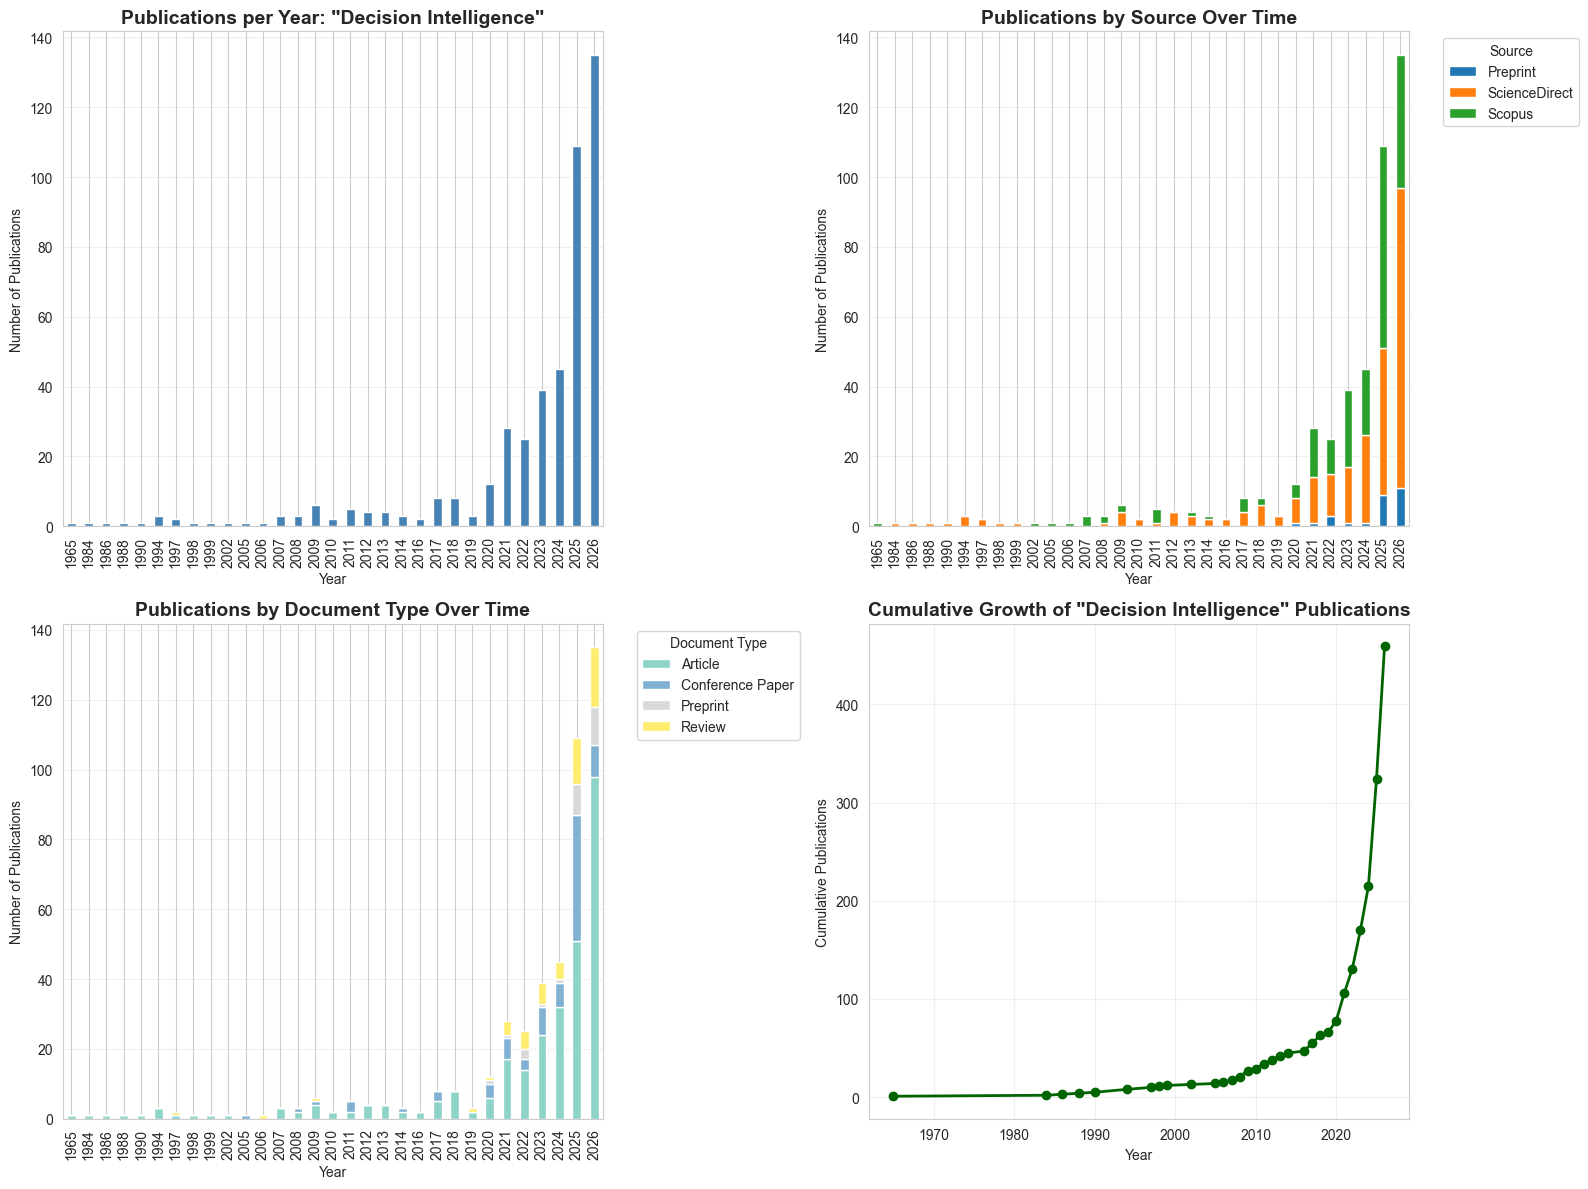


📈 Key Statistics:
  First publication: 1965
  Latest publication: 2026
  Peak year: 2026 (135 publications)
  Average per year: 14.8


In [23]:
# Publications by year
yearly_counts = dedup_df.groupby('year').size().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Overall temporal trend
ax1 = axes[0, 0]
yearly_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Publications per Year: "Decision Intelligence"', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Publications')
ax1.grid(axis='y', alpha=0.3)

# 2. By source
ax2 = axes[0, 1]
source_year = dedup_df.groupby(['year', 'source']).size().unstack(fill_value=0)
source_year.plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title('Publications by Source Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Publications')
ax2.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

# 3. By document type
ax3 = axes[1, 0]
doctype_year = dedup_df.groupby(['year', 'document_type']).size().unstack(fill_value=0)
doctype_year.plot(kind='bar', stacked=True, ax=ax3, colormap='Set3')
ax3.set_title('Publications by Document Type Over Time', fontsize=14, fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Publications')
ax3.legend(title='Document Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(axis='y', alpha=0.3)

# 4. Cumulative growth
ax4 = axes[1, 1]
cumulative = yearly_counts.cumsum()
cumulative.plot(kind='line', ax=ax4, marker='o', linewidth=2, markersize=6, color='darkgreen')
ax4.set_title('Cumulative Growth of "Decision Intelligence" Publications', fontsize=14, fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Cumulative Publications')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📈 Key Statistics:")
print(f"  First publication: {yearly_counts.index.min():.0f}")
print(f"  Latest publication: {yearly_counts.index.max():.0f}")
print(f"  Peak year: {yearly_counts.idxmax():.0f} ({yearly_counts.max()} publications)")
print(f"  Average per year: {yearly_counts.mean():.1f}")

## 8. Source and Document Type Distribution

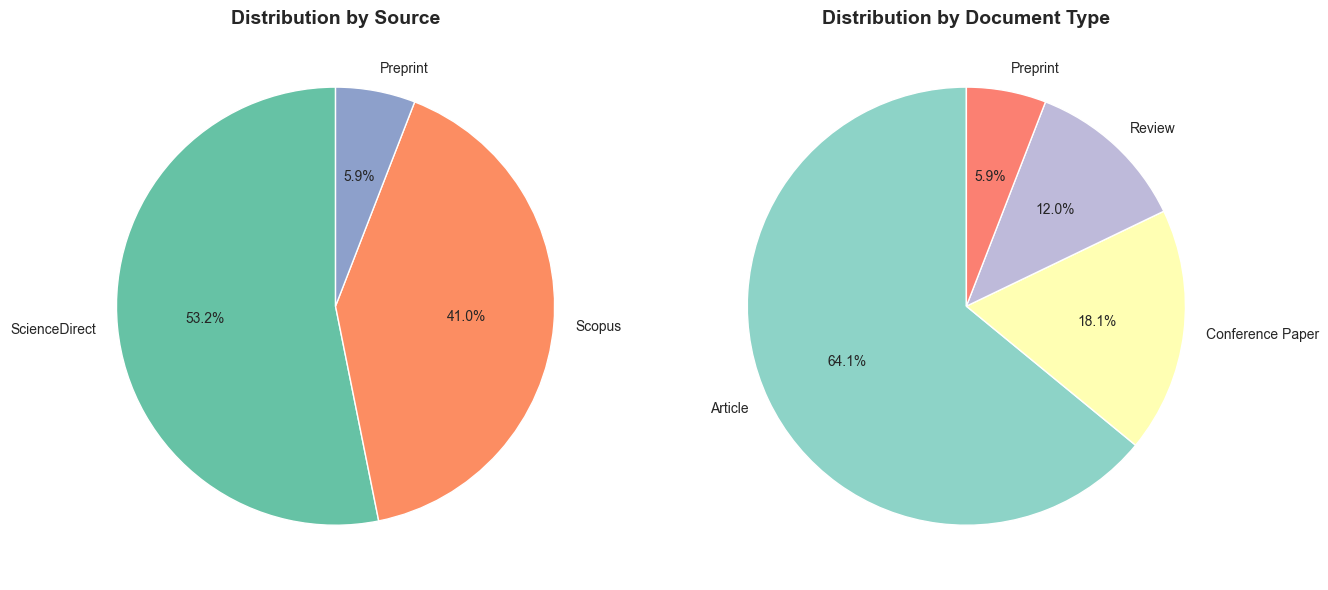

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Source distribution
ax1 = axes[0]
source_counts = dedup_df['source'].value_counts()
colors = sns.color_palette('Set2', len(source_counts))
ax1.pie(source_counts.values, labels=source_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors)
ax1.set_title('Distribution by Source', fontsize=14, fontweight='bold')

# Document type distribution
ax2 = axes[1]
doctype_counts = dedup_df['document_type'].value_counts()
colors = sns.color_palette('Set3', len(doctype_counts))
ax2.pie(doctype_counts.values, labels=doctype_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
ax2.set_title('Distribution by Document Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Summary Statistics

In [25]:
print("="*80)
print("DECISION INTELLIGENCE EVOLUTION - SUMMARY REPORT")
print("="*80)

print(f"\n📊 DATASET OVERVIEW")
print(f"  Total unique publications: {len(dedup_df)}")
print(f"  Document types: Article, Review, Conference Paper only")
print(f"  Time span: {dedup_df['year'].min():.0f} - {dedup_df['year'].max():.0f}")

print(f"\n📚 BY SOURCE")
for source, count in dedup_df['source'].value_counts().items():
    pct = count / len(dedup_df) * 100
    print(f"  {source}: {count} ({pct:.1f}%)")

print(f"\n📄 BY DOCUMENT TYPE")
for dtype, count in dedup_df['document_type'].value_counts().items():
    pct = count / len(dedup_df) * 100
    print(f"  {dtype}: {count} ({pct:.1f}%)")

print(f"\n📈 TEMPORAL TRENDS")
recent_5y = dedup_df[dedup_df['year'] >= dedup_df['year'].max() - 4]
print(f"  Publications in last 5 years: {len(recent_5y)} ({len(recent_5y)/len(dedup_df)*100:.1f}%)")
print(f"  Average per year (overall): {len(dedup_df)/(dedup_df['year'].max()-dedup_df['year'].min()+1):.1f}")
print(f"  Growth rate (last 5 years): {len(recent_5y)/5:.1f} pubs/year")

print(f"\n🔍 DATA QUALITY")
print(f"  Records with abstracts: {dedup_df['abstract'].notna().sum()} ({dedup_df['abstract'].notna().sum()/len(dedup_df)*100:.1f}%)")
print(f"  Records with keywords: {dedup_df['keywords'].notna().sum()} ({dedup_df['keywords'].notna().sum()/len(dedup_df)*100:.1f}%)")
print(f"  Records with DOI: {dedup_df['doi'].notna().sum()} ({dedup_df['doi'].notna().sum()/len(dedup_df)*100:.1f}%)")

print("\n" + "="*80)

DECISION INTELLIGENCE EVOLUTION - SUMMARY REPORT

📊 DATASET OVERVIEW
  Total unique publications: 459
  Document types: Article, Review, Conference Paper only
  Time span: 1965 - 2026

📚 BY SOURCE
  ScienceDirect: 244 (53.2%)
  Scopus: 188 (41.0%)
  Preprint: 27 (5.9%)

📄 BY DOCUMENT TYPE
  Article: 294 (64.1%)
  Conference Paper: 83 (18.1%)
  Review: 55 (12.0%)
  Preprint: 27 (5.9%)

📈 TEMPORAL TRENDS
  Publications in last 5 years: 353 (76.9%)
  Average per year (overall): 7.4
  Growth rate (last 5 years): 70.6 pubs/year

🔍 DATA QUALITY
  Records with abstracts: 457 (99.6%)
  Records with keywords: 395 (86.1%)
  Records with DOI: 423 (92.2%)



## 10. Export Integrated Dataset

In [ ]:
# Export the integrated and deduplicated dataset
output_file = 'decision_intelligence_integrated.csv'
dedup_df.to_csv(output_file, index=False, encoding='utf-8')

print(f"✓ Integrated dataset exported to: {output_file}")
print(f"  Columns: {', '.join(dedup_df.columns)}")
print(f"  Records: {len(dedup_df)}")
print(f"  Document types: {', '.join(dedup_df['document_type'].unique())}")